In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import (classification_report, confusion_matrix, 
                            ConfusionMatrixDisplay, f1_score, roc_auc_score, roc_curve,
                            roc_auc_score, precision_recall_curve, average_precision_score)

from imblearn.combine import SMOTEENN

# hyperparameter tuning
import optuna

# explainability
import shap

# for saving our final model
import joblib

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

In [2]:
df = pd.read_csv('EDA_telco_churn.csv')
df.head()

,SeniorCitizen,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_group_13 - 24,tenure_group_25 - 36,tenure_group_37 - 48,tenure_group_49 - 60,tenure_group_61 - 72
0,0,29.85,29.85,0,False,True,False,False,True,False,...,False,True,False,True,False,False,False,False,False,False
1,0,56.95,1889.50,0,True,False,False,True,False,False,...,False,False,False,False,True,False,True,False,False,False
2,0,53.85,108.15,1,True,False,False,True,False,False,...,False,True,False,False,True,False,False,False,False,False
3,0,42.30,1840.75,0,True,False,False,False,True,False,...,False,False,False,False,False,False,False,True,False,False
4,0,70.70,151.65,1,False,False,False,True,False,False,...,False,True,False,True,False,False,False,False,False,False


In [3]:
# counting and separating bool columns
bool_cols = df.select_dtypes(include = 'bool').columns
print(len(bool_cols))

# converting bools(True/False) into 0/1 
df[bool_cols] = df[bool_cols].astype(int)

df.dtypes.value_counts()

31


int64      33
float64     2
Name: count, dtype: int64

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 35 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7032 non-null   int64  
 1   MonthlyCharges                         7032 non-null   float64
 2   TotalCharges                           7032 non-null   float64
 3   Churn                                  7032 non-null   int64  
 4   gender_Male                            7032 non-null   int64  
 5   Partner_Yes                            7032 non-null   int64  
 6   Dependents_Yes                         7032 non-null   int64  
 7   PhoneService_Yes                       7032 non-null   int64  
 8   MultipleLines_No phone service         7032 non-null   int64  
 9   MultipleLines_Yes                      7032 non-null   int64  
 10  InternetService_Fiber optic            7032 non-null   int64  
 11  Inte

In [5]:
# Calculatin correlation with churn

corr_with_churn = df.corr(numeric_only = True)['Churn'].abs().sort_values()
# numeric_only = True -> ignores all non-numeric columns like strings 
# .abs -> converts all values to +ve

# Checking the 10 least correlated features
corr_with_churn.head(10)

gender_Male                       0.008545
PhoneService_Yes                  0.011691
MultipleLines_No phone service    0.011691
tenure_group_13 - 24              0.019929
MultipleLines_Yes                 0.040033
tenure_group_25 - 36              0.040997
tenure_group_37 - 48              0.059579
StreamingMovies_Yes               0.060860
StreamingTV_Yes                   0.063254
DeviceProtection_Yes              0.066193
Name: Churn, dtype: float64

In [6]:
# Based on the correlation check above, these three features have near-zero
# 'gender_Male', 'PhoneService_Yes', 'MultipleLines_No phone service'

drop_cols = ['gender_Male', 'PhoneService_Yes', 'MultipleLines_No phone service']
df.shape

# dropping these 3 features
df = df.drop(columns = drop_cols)

df.shape

(7032, 32)

In [7]:
# defining X and y

X = df.drop(columns='Churn')
y = df['Churn']

X.shape, y.shape

((7032, 31), (7032,))

In [8]:
# train test split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2,random_state=42, 
    stratify=y,         # preserve the 73:27 churn ratio in both splits
)


# Train churn ratio
print(y_train.value_counts(normalize=True))

# Test churn ratio
print(y_test.value_counts(normalize=True))

Churn
0    0.734222
1    0.265778
Name: proportion, dtype: float64
Churn
0    0.734186
1    0.265814
Name: proportion, dtype: float64


In [9]:
# SMOTEENN
# SMOTE -> Adds new samples to the minority class.
# ENN ->  Removes noisy/overlapping/wrongly placed samples from both classes.
# Results in a cleaner and more balanced dataset

# However, for LightGBM and XGBoost, SMOTEENN is often not necessary because these algorithms already have
# built-in ways to handle class imbalance, such as:
# LightGBM → is_unbalance=True or scale_pos_weight
# XGBoost → scale_pos_weight 

# SMOTEENN is applied only to the training set to avoid data leakage 
# the test set must remain unchanged so it reflects real-world data and 
# provides an unbiased evaluation.

In [10]:
print(X_train.shape, y_train.shape)
print(y_train.value_counts(normalize=True))

(5625, 31) (5625,)
Churn
0    0.734222
1    0.265778
Name: proportion, dtype: float64


In [11]:
sme = SMOTEENN(random_state=42)

# fit_resample learns from the training data and returns a new, resampled version
X_train_res, y_train_res = sme.fit_resample(X_train, y_train)

print('Resampled training shape (X) : ', X_train_res.shape)
print('Resampled training shape (y) : ', y_train_res.shape)

print("\nResampled churn ratio:")
print(y_train_res.value_counts(normalize=True))

Resampled training shape (X) :  (4595, 31)
Resampled training shape (y) :  (4595,)

Resampled churn ratio:
Churn
1    0.525789
0    0.474211
Name: proportion, dtype: float64


## Baseline Model - Decision Tree

In [12]:
# create a decision tree model as baseline model
dt_baseline = DecisionTreeClassifier(random_state=42)

# training on original dataset
dt_baseline.fit(X_train, y_train)

# prediction on untouched test dataset
y_pred_baseline = dt_baseline.predict(X_test)

In [13]:
# Classification report for baseline model
classification_report(y_test, y_pred_baseline)

'              precision    recall  f1-score   support\n\n           0       0.81      0.81      0.81      1033\n           1       0.48      0.49      0.49       374\n\n    accuracy                           0.73      1407\n   macro avg       0.65      0.65      0.65      1407\nweighted avg       0.73      0.73      0.73      1407\n'

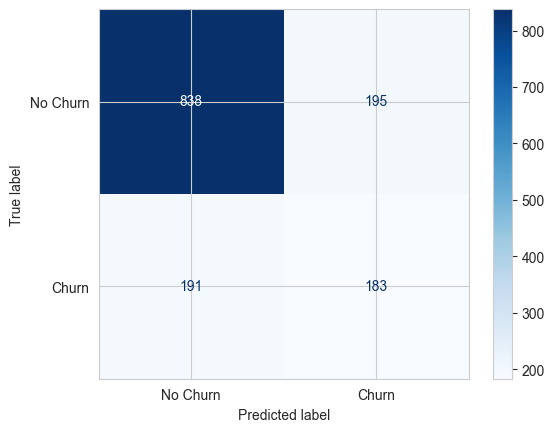

In [14]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred_baseline)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
disp.plot(cmap='Blues')
# plt.title('Baseline Decision Tree')
plt.show()

From our baseline Decision Tree, we can conclude:

* Accuracy = 73% → The model performs reasonably overall, but accuracy alone is misleading because the dataset is imbalanced.
* Recall (Churn = 1) = 49% → It correctly identifies only 183 out of 374 churn customers, missing 191 churners. This is the biggest weakness.
* Precision (Churn = 1) = 48% → When the model predicts churn, it’s correct only about half the time.
* Confusion Matrix → It predicts No Churn much better (838 correct) than Churn (183 correct), showing a bias toward the majority class.

## Decsion Tree + SMOTEENN

In [15]:
dt_sme = DecisionTreeClassifier(random_state=42)

# training on the resample(SMOTEENN) data
dt_sme.fit(X_train_res, y_train_res)

# but making prediction on the original dataset only
y_pred_dt_sme = dt_sme.predict(X_test)

In [16]:
# Classification report for Decision tree + smoteenn
classification_report(y_test, y_pred_dt_sme)

'              precision    recall  f1-score   support\n\n           0       0.87      0.75      0.81      1033\n           1       0.50      0.70      0.58       374\n\n    accuracy                           0.73      1407\n   macro avg       0.69      0.72      0.69      1407\nweighted avg       0.77      0.73      0.75      1407\n'

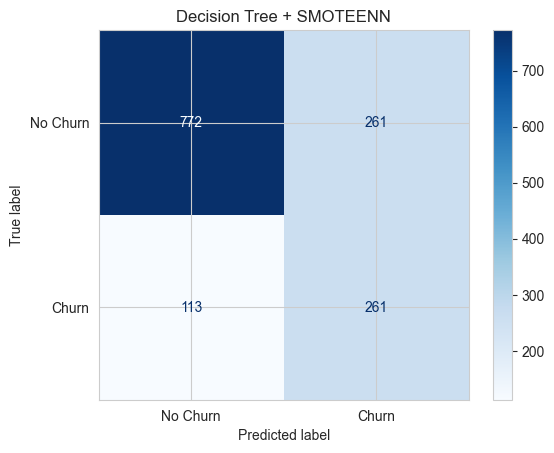

In [17]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred_dt_sme)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
disp.plot(cmap='Blues')
plt.title('Decision Tree + SMOTEENN')
plt.show()

Compared to the baseline model:

* Accuracy increased slightly (73% → 75%), but accuracy is not the main focus for an imbalanced dataset.
* Recall for Churn (class 1) improved significantly (49% → 70%), meaning the model now correctly identifies 261 out of 374 churners instead of 183.
* F1-score for Churn improved (0.49 → 0.58), showing a better balance between precision and recall.
* Trade-off: False negatives decreased (191 → 113), but false positives increased (195 → 261). The model catches more churners but also wrongly flags more non-churn customers.

## Random Forest with 'class_weight = balanced'

In [18]:
# class_weight='balanced' tells the Random Forest to automatically give 
# more importance (higher weight) to the minority class and less importance 
# to the majority class during training.

# SMOTEENN → Changes the training data by creating/removing samples.
# class_weight='balanced' → Does not change the data; 
# it only changes how much the model cares about each class during training.


In [19]:
rf_balanced = RandomForestClassifier(class_weight = 'balanced', random_state = 42) 

# Trained on the ORIGINAL training data, class_weight handles the imbalance internally,
# so we don't need SMOTEENN here
rf_balanced.fit(X_train, y_train)

# prediction on original datset
y_pred_rf_balanced = rf_balanced.predict(X_test)

In [20]:
# Classification report for Random Forest with class_weights = balanced
classification_report(y_test, y_pred_rf_balanced)

'              precision    recall  f1-score   support\n\n           0       0.83      0.88      0.85      1033\n           1       0.60      0.49      0.54       374\n\n    accuracy                           0.78      1407\n   macro avg       0.71      0.68      0.69      1407\nweighted avg       0.76      0.78      0.77      1407\n'

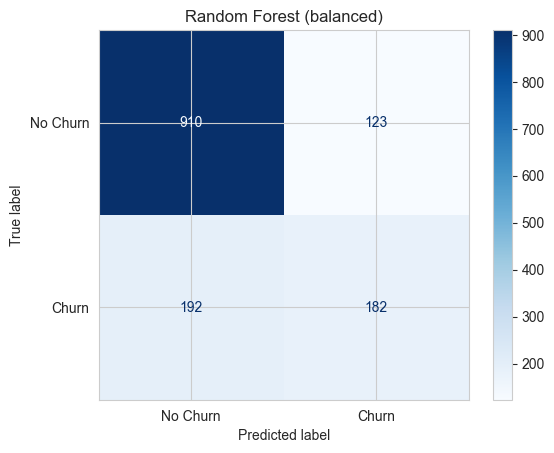

In [21]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred_rf_balanced)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
disp.plot(cmap='Blues')
plt.title('Random Forest (balanced)')
plt.show()

Compared to the previous models:

* Accuracy improved to 78%, and the model predicts No Churn very well (910 correct).
* Precision for Churn = 60%, meaning churn predictions are more reliable than before.
* Recall for Churn = 49%, which is the same as the baseline Decision Tree, so it still misses 192 out of 374 churners.
* Trade-off: Compared to SMOTEENN, it has fewer false positives (123 vs 261) but more false negatives (192 vs 113).

Conclusion:

Using class_weight='balanced' improved overall accuracy and precision without changing the data, but it did not improve churn detection (recall) as much as SMOTEENN, making SMOTEENN the better choice when catching churners is the priority.

## Random Forest + SMOTEEN

In [22]:
rf_sme = RandomForestClassifier(random_state=42)

# training on the resample(SMOTEENN) data
rf_sme.fit(X_train_res, y_train_res)

# but making prediction on the original dataset only
y_pred_rf_sme = rf_sme.predict(X_test)

In [23]:
# Classification report for Random Forest + smoteenn
classification_report(y_test, y_pred_rf_sme)

'              precision    recall  f1-score   support\n\n           0       0.89      0.77      0.83      1033\n           1       0.54      0.74      0.62       374\n\n    accuracy                           0.76      1407\n   macro avg       0.71      0.75      0.72      1407\nweighted avg       0.80      0.76      0.77      1407\n'

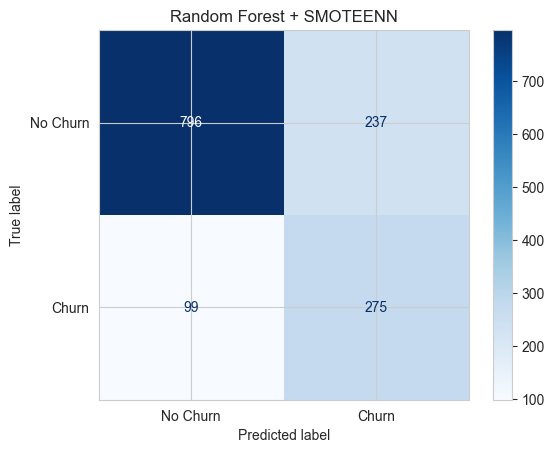

In [24]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred_rf_sme)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
disp.plot(cmap='Blues')
plt.title('Random Forest + SMOTEENN')
plt.show()

* Recall for Churn improved to 74% and F1-score to 0.62, making it the best-performing model so far at identifying churn customers.
* Trade-off: It catches many more churners (275 vs 182/183 previously) but also increases false positives (237).

Overall conclusion:

*Random Forest + SMOTEENN* is the strongest model among the four tested so far, achieving the highest F1-score and recall for the churn class. It catches the most churners, though at the cost of more false positives, making it a strong benchmark before trying LightGBM.

## LightGBM Model with scale_pos_weight

In [25]:
# scale_pos_weight and SMOTEENN have the same goal—handling class imbalance
# but they do it differently.

# SMOTEENN balances the dataset by creating synthetic minority samples 
# and removing noisy ones.

# scale_pos_weight leaves the data unchanged and simply tells 
# LightGBM to give more importance (higher penalty) to mistakes 
# on the minority class during training.

In [26]:
# scale_pos_weight = (Total No Churn samples) / (Total Churn samples)
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# (y_train == 0).sum() → Counts the number of No Churn (class 0) samples.
# (y_train == 1).sum() → Counts the number of Churn (class 1) samples.
# Dividing them gives the class imbalance ratio.

print(f"scale_pos_weight = {scale_pos_weight:.3f}")

scale_pos_weight = 2.763


In [27]:
lgbm = LGBMClassifier(
    scale_pos_weight = scale_pos_weight,
    random_state = 42,
    verbose = -1 # It is used to keep the notebook output clean by hiding LightGBM’s internal training messages.
)

In [28]:
# Training on the original dataset
lgbm.fit(X_train , y_train)

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [29]:
'''Threshold tuning changes the probability cutoff for predicting churn 
(e.g., from 0.5 to 0.4) instead of using the default threshold. 
Lowering the threshold increases recall (catches more churners) 
but decreases precision (more false positives).'''


y_proba = lgbm.predict_proba(X_test)[:, 1]
# predict_proba() returns the probability of both classes for every sample.
# [:, 1] selects only the probability of Class 1 (Churn).

y_pred_t50 = (y_proba >= 0.5).astype(int)
# If probability ≥ 0.5 → predict 1 (Churn).
# Otherwise → predict 0 (No Churn).


y_pred_t40 = (y_proba >= 0.4).astype(int)
# Uses a lower threshold (0.4).
# If probability ≥ 0.4 → predict 1 (Churn).

In [30]:
classification_report(y_test, y_pred_t50)

'              precision    recall  f1-score   support\n\n           0       0.89      0.75      0.82      1033\n           1       0.52      0.76      0.62       374\n\n    accuracy                           0.75      1407\n   macro avg       0.71      0.75      0.72      1407\nweighted avg       0.80      0.75      0.76      1407\n'

In [31]:
classification_report(y_test, y_pred_t40)

'              precision    recall  f1-score   support\n\n           0       0.91      0.68      0.78      1033\n           1       0.48      0.82      0.61       374\n\n    accuracy                           0.72      1407\n   macro avg       0.70      0.75      0.69      1407\nweighted avg       0.80      0.72      0.73      1407\n'

Lowering the threshold (0.5 → 0.4) increases recall but decreases precision. The best threshold depends on your business goal (catching more churners vs. reducing false alarms), so there is no universally best threshold.


* Lowering the threshold (0.5 → 0.4) increases recall but decreases precision.
* 0.4 is not always better; the best threshold depends on the F1-score and the business trade-off between missed churners and false alarms.
* There is no universally best threshold—it is a business decision, not just a statistical one.
* The default threshold (0.5) is carried forward for tuning because F1-score is the optimization metric used by Optuna.

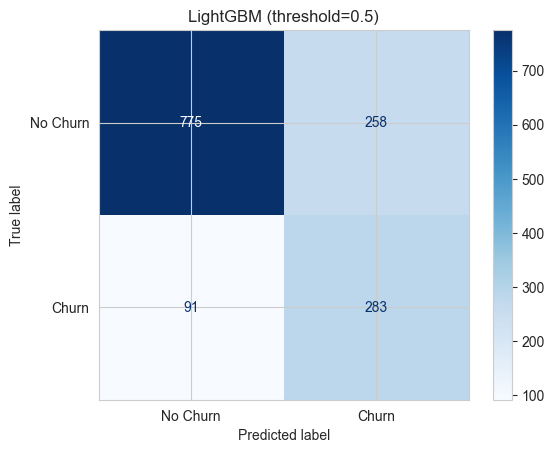

In [32]:
cm = confusion_matrix(y_test, y_pred_t50)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
disp.plot(cmap='Blues')
plt.title('LightGBM (threshold=0.5)')
plt.show()

Threshold = 0.5

* Precision = 52%, Recall = 76%, F1-score = 0.62 for the churn class.
* Correctly identifies 283 out of 374 churn customers, missing 91.

Threshold = 0.4

* Recall increases to 82%, but Precision drops to 48%, with F1-score slightly decreasing to 0.61.
* The model catches more churners but also generates more false positives.

LightGBM (threshold = 0.5) is the best overall model because it provides the best balance between precision and recall, achieving the highest recall (76%) while maintaining the highest F1-score (0.62). If the business prioritizes catching as many churners as possible, LightGBM with a 0.4 threshold is the better choice due to its 82% recall.

## Hyperparameter Tuning (Optuna)

In [33]:
# Optuna automatically finds the best hyperparameters instead of manually trying different combinations.
# It uses TPE (Tree-structured Parzen Estimator), a Bayesian optimization method, to make smarter choices based on previous trials.
# We define:
#     Search space → The range of hyperparameter values Optuna can try.
#     Objective function → The metric to maximize (here, F1-score for the churn class).
#     50 trials → Optuna tests 50 different hyperparameter combinations and selects the best one.

In [34]:
def objective(trial):
    # Optuna suggests a value for each hyperparameter within the ranges we define.
    # trial.suggest_int / suggest_float tell Optuna what type and range to search.
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 15, 100),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'scale_pos_weight': scale_pos_weight,  # keep this fixed — it's not a tuning target
        'random_state': 42,
        'verbose': -1
    }

    model = LGBMClassifier(**params)
    model.fit(X_train, y_train)

    proba = model.predict_proba(X_test)[:, 1]
    preds = (proba >= 0.5).astype(int)

    # This is what Optuna is trying to maximize
    return f1_score(y_test, preds)

In [35]:
# This code tells Optuna to try 50 different LightGBM hyperparameter combinations, 
# find the one with the highest F1-score, and print the best score and corresponding parameters.

# Suppresses Optuna’s detailed trial logs, showing only warnings to keep the notebook output clean.
optuna.logging.set_verbosity(optuna.logging.WARNING)

# direction='maximize' because we want the HIGHEST f1 score
study = optuna.create_study(direction = 'maximize')

# Run 50 trials — each trial trains and evaluates one full LightGBM model
study.optimize(objective, n_trials=50)


print("Best F1 score found:", study.best_value)
print("Best parameters:", study.best_params)

Best F1 score found: 0.6485875706214689
Best parameters: {'n_estimators': 116, 'max_depth': 12, 'learning_rate': 0.013488859506038361, 'num_leaves': 85, 'min_child_samples': 45}


In [36]:
# getting the best hyperparameters founded by optuna
best_params = study.best_params

# keeping some  values fixed
best_params['scale_pos_weight'] = scale_pos_weight
best_params['random_state'] = 42
best_params['verbose'] = -1

In [37]:
# LGBM Classifier TUNED Model:

lgbm_tuned = LGBMClassifier(**best_params)
lgbm_tuned.fit(X_train, y_train)

# predicts the label(0/1) for test data
y_pred_tuned = lgbm_tuned.predict(X_test)

# Gets the probability that each customer belongs to class 1 (Churn).
y_proba_tuned = lgbm_tuned.predict_proba(X_test)[:, 1]

In [38]:
# Classification report

classification_report(y_test, y_pred_tuned)

'              precision    recall  f1-score   support\n\n           0       0.90      0.78      0.84      1033\n           1       0.56      0.77      0.65       374\n\n    accuracy                           0.78      1407\n   macro avg       0.73      0.78      0.74      1407\nweighted avg       0.81      0.78      0.79      1407\n'

## MODEL EVALUATION

In [39]:
# Collect predictions/probabilities from every model we made
models_results = {
    'Decision Tree (baseline)': (y_pred_baseline, None),
    'Decision Tree + SMOTEENN': (y_pred_dt_sme, None),
    'Random Forest (balanced)': (y_pred_rf_balanced, rf_balanced.predict_proba(X_test)[:, 1]),
    'Random Forest + SMOTEENN': (y_pred_rf_sme, rf_sme.predict_proba(X_test)[:, 1]),
    'LightGBM (default params)': (y_pred_t50, y_proba),
    'LightGBM (Optuna-tuned)': (y_pred_tuned, y_proba_tuned),
}

rows = []
for name, (preds, proba) in models_results.items():
    report = classification_report(y_test, preds, output_dict=True)
    row = {
        'Model': name,
        'Precision (Churn)': report['1']['precision'],
        'Recall (Churn)': report['1']['recall'],
        'F1 (Churn)': report['1']['f1-score'],
        'ROC-AUC': roc_auc_score(y_test, proba) if proba is not None else np.nan
    }
    rows.append(row)

comparison_df = pd.DataFrame(rows).set_index('Model').round(3)
comparison_df

,Precision (Churn),Recall (Churn),F1 (Churn),ROC-AUC
Model,,,,
Decision Tree (baseline),0.484,0.489,0.487,NaN
Decision Tree + SMOTEENN,0.500,0.698,0.583,NaN
Random Forest (balanced),0.597,0.487,0.536,0.812
Random Forest + SMOTEENN,0.537,0.735,0.621,0.823
LightGBM (default params),0.523,0.757,0.619,0.830
LightGBM (Optuna-tuned),0.562,0.767,0.649,0.834


* ROC-AUC requires predicted probabilities (predict_proba), not just class predictions (predict).
* The Decision Tree models used only .predict(), so ROC-AUC wasn’t calculated. It was omitted to keep the comparison focused on LightGBM, where probability-based predictions and threshold tuning are important.

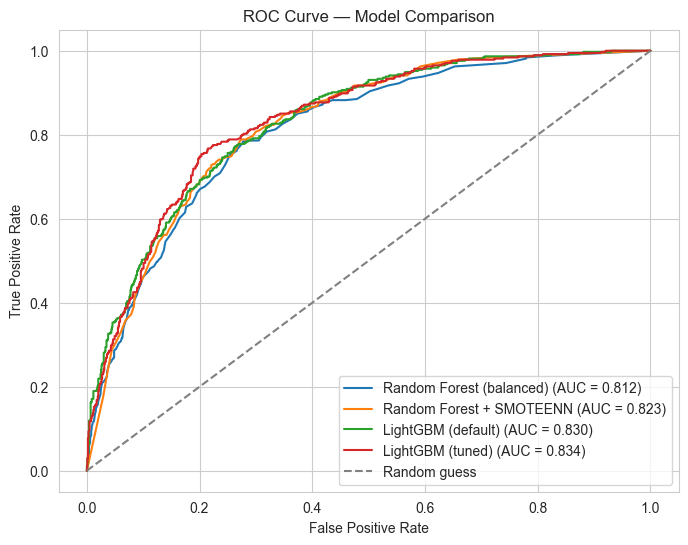

In [40]:
# ROC-AUC curve — compares models on how well they rank churners above non-churners
# across ALL possible thresholds, not just one fixed cutoff
plt.figure(figsize=(8, 6))

roc_models = {
    'Random Forest (balanced)': rf_balanced.predict_proba(X_test)[:, 1],
    'Random Forest + SMOTEENN': rf_sme.predict_proba(X_test)[:, 1],
    'LightGBM (default)': y_proba,
    'LightGBM (tuned)': y_proba_tuned,
}

for name, proba in roc_models.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

# The diagonal line represents a model making random guesses — our curves should sit above it
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Model Comparison')
plt.legend()
plt.show()

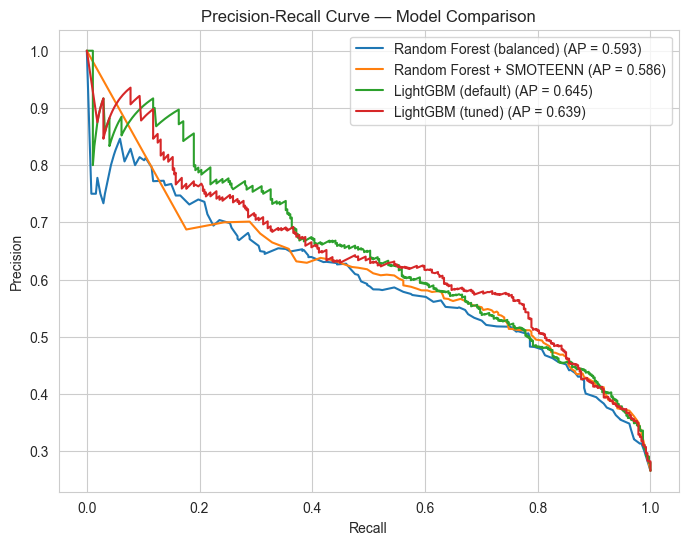

In [41]:
plt.figure(figsize=(8, 6))

for name, proba in roc_models.items():
    precision, recall, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    plt.plot(recall, precision, label=f'{name} (AP = {ap:.3f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve — Model Comparison')
plt.legend()
plt.show()

## Explainability - SHAP

In [42]:
'''A model that predicts well but can't explain why isn't very useful 
in a business context like churn — stakeholders want to know which 
factors are driving the prediction, not just the prediction itself. 
SHAP (SHapley Additive exPlanations) assigns every feature a contribution 
value for every prediction, based on game theory, telling us exactly how 
much each feature pushed the prediction up or down.'''

# We use the **tuned LightGBM model** for this, since it's our best and final model.



"A model that predicts well but can't explain why isn't very useful \nin a business context like churn — stakeholders want to know which \nfactors are driving the prediction, not just the prediction itself. \nSHAP (SHapley Additive exPlanations) assigns every feature a contribution \nvalue for every prediction, based on game theory, telling us exactly how \nmuch each feature pushed the prediction up or down."

In [43]:
# TreeExplainer is optimized specifically for tree-based models like LightGBM —
# much faster than the general-purpose SHAP explainer
explainer = shap.TreeExplainer(lgbm_tuned)

# Computes SHAP values for every row in the test set
shap_values = explainer(X_test)
shap_values.values

print("SHAP values shape:", shap_values.shape)

SHAP values shape: (1407, 31)


This is a SHAP Global Feature Importance plot.

* It shows which features have the greatest overall impact on the LightGBM model’s predictions across all customers.
* The features are ranked from most important (top) to least important (bottom).
* The longer the bar, the greater the average influence of that feature on the model’s predictions.
* The x-axis (mean(|SHAP value|)) represents the average absolute SHAP value, i.e., the average magnitude of a feature’s contribution (whether it increases or decreases churn).

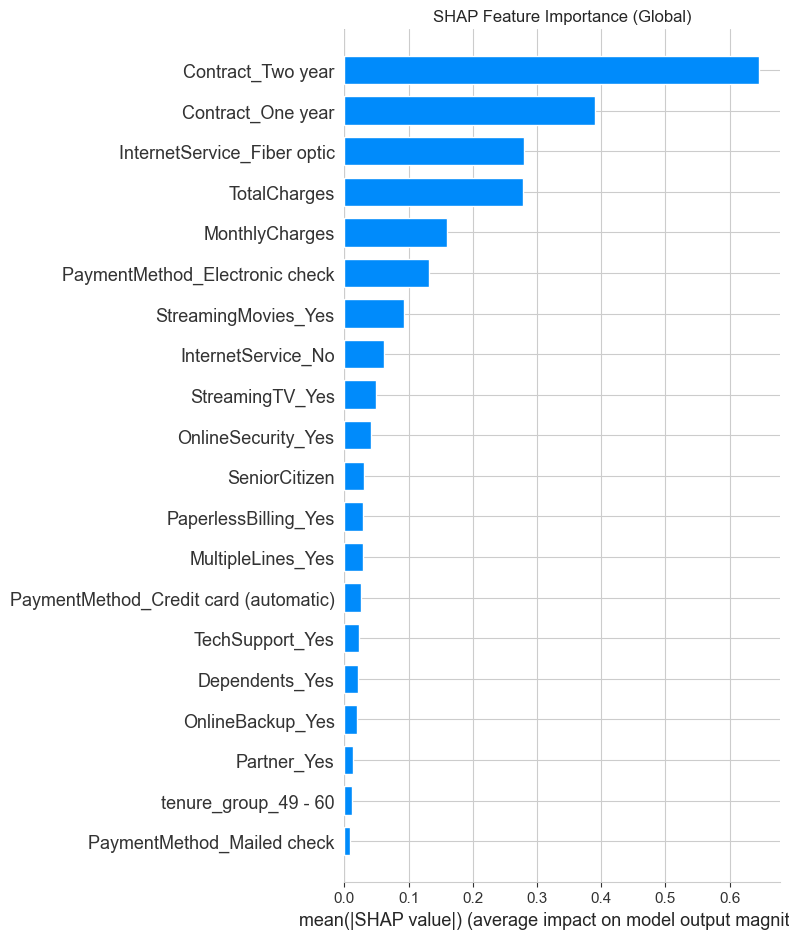

In [44]:
shap.summary_plot(shap_values, X_test, plot_type='bar', show=False)
plt.title('SHAP Feature Importance (Global)')
plt.tight_layout()
plt.show()

* Contract_Two year is the most influential feature, meaning it has the largest impact on predicting customer churn.
* Contract_One year is the second most important feature.
* InternetService_Fiber optic, TotalCharges, and MonthlyCharges are also major factors affecting churn.
* Features near the bottom (e.g., Partner_Yes, tenure_group_25-36) have very little influence on the model’s predictions.

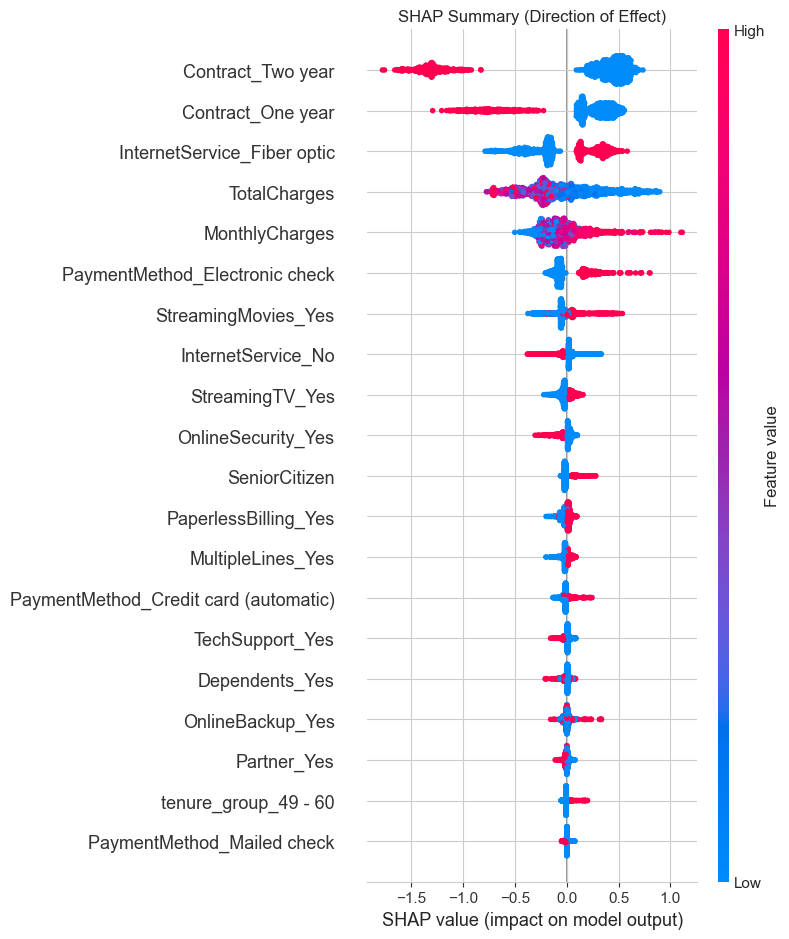

In [45]:
shap.summary_plot(shap_values, X_test, show=False)
plt.title('SHAP Summary (Direction of Effect)')
plt.tight_layout()
plt.show()

* Two-year and one-year contracts mostly have negative SHAP values, meaning they reduce the likelihood of churn.
* Fiber optic internet and higher monthly charges generally have positive SHAP values, meaning they increase the likelihood of churn.
* Higher total charges tend to reduce churn, likely because they are associated with long-term customers.
* Most remaining features have a much smaller impact on the model’s predictions.

In [46]:
# Rather than picking a random row, we deliberately find a customer the model is
# confident WILL churn — that way the waterfall plot actually demonstrates what
# "explaining a churn prediction" looks like, instead of explaining a random outcome.

test_probas = lgbm_tuned.predict_proba(X_test)[:, 1]
sample_idx = np.argmax(test_probas) 
 # index of the highest predicted churn probability in the test set

print("Customer's predicted churn probability:", round(test_probas[sample_idx], 3))
print("Customer's actual outcome (1 = churned):", y_test.iloc[sample_idx])

Customer's predicted churn probability: 0.829
Customer's actual outcome (1 = churned): 1


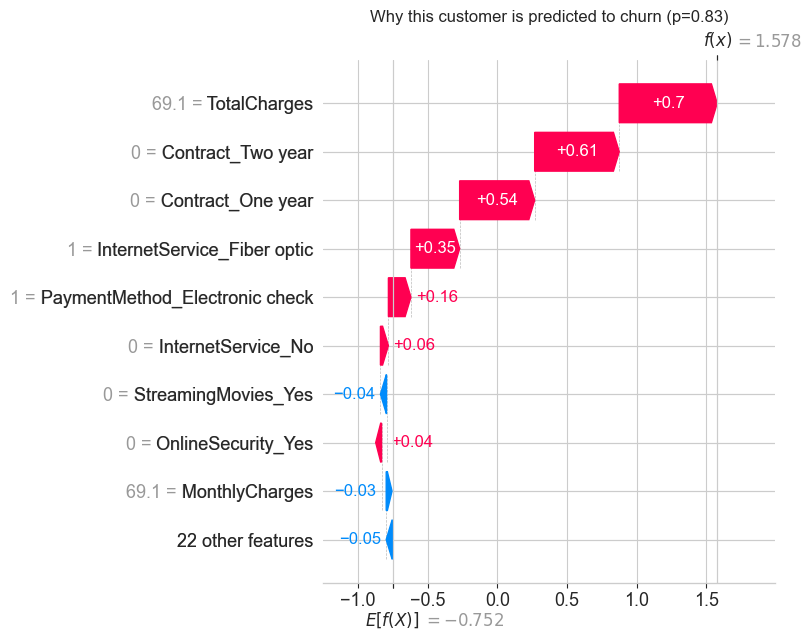

In [47]:
# explainer(X) (calling it directly) returns a richer Explanation object needed for waterfall plots,
# unlike explainer.shap_values(X) which returns plain arrays
single_explanation = explainer(X_test.iloc[[sample_idx]])

shap.plots.waterfall(single_explanation[0], show=False)
plt.title(f'Why this customer is predicted to churn (p={test_probas[sample_idx]:.2f})')
plt.tight_layout()
plt.show()

* The biggest reasons this customer is predicted to churn are:
    * Low TotalCharges (+0.64)
    * No Two-Year Contract (+0.63)
    * No One-Year Contract (+0.52)
    * Fiber Optic Internet (+0.30)
    * Electronic Check Payment (+0.18)
* A few features like MonthlyCharges, StreamingMovies, and other small factors slightly reduce the churn prediction, but their effect is much smaller.

## Saving the Model

In [48]:
# Save the tuned model to disk
joblib.dump(lgbm_tuned, 'churn_model_lightgbm.pkl')

['churn_model_lightgbm.pkl']

In [49]:
# Load it back and verify it still produces identical predictions
loaded_model = joblib.load('churn_model_lightgbm.pkl')

original_preds = lgbm_tuned.predict(X_test)
loaded_preds = loaded_model.predict(X_test)

predictions_match = np.array_equal(original_preds, loaded_preds)
print("Loaded model predictions match original model:", predictions_match)

Loaded model predictions match original model: True


Final Insights & Conclusion

* A Decision Tree was first trained as the baseline model to establish a benchmark for comparison. It struggled to identify churn customers due to the class imbalance.
* Applying SMOTEENN significantly improved the model’s recall by helping it detect more churners, although this came with an increase in false positives.
* Random Forest with class_weight='balanced' improved overall accuracy but still missed many churn customers. Combining Random Forest + SMOTEENN further improved recall and F1-score, making it the best Random Forest variant.
* LightGBM outperformed all previous models by effectively handling class imbalance using scale_pos_weight, eliminating the need for SMOTEENN while achieving the best overall balance between precision and recall.
* Threshold tuning demonstrated the trade-off between precision and recall. Lowering the threshold from 0.5 to 0.4 increased recall but reduced precision, showing that the optimal threshold depends on business priorities.
* Optuna was used to automatically tune the LightGBM hyperparameters, resulting in an improved final model with better predictive performance than the default configuration.
* SHAP analysis made the final model interpretable by identifying the most influential features. The analysis showed that contract type, internet service, total charges, and monthly charges were the strongest drivers of customer churn.

Final Model Selection

The Optuna-tuned LightGBM model (threshold = 0.5) was selected as the final model because it achieved the best overall balance of Precision, Recall, and F1-score, while also providing explainable predictions through SHAP. This makes it the most suitable model for predicting customer churn and supporting business decisions on customer retention.